In [1]:
import os

os.environ['KAGGLE_USERNAME'] = "Shirwin prince"
os.environ['KAGGLE_KEY'] = "KGAT_e245ee737d38219a541f77433449e8e2"

In [2]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
100% 39.3k/39.3k [00:00<00:00, 18.0MB/s]



In [3]:
import zipfile
import os

# Path to your zip file
zip_path = "/content/dataset-for-dbscan.zip"
extract_path = "extracted_files"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract all files
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Files extracted to:", extract_path)

✅ Files extracted to: extracted_files


In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
# Step 2: Load dataset
data = pd.read_csv("/content/extracted_files/Clustering_gmm (2).csv")
print("First 5 rows:\n", data.head())

First 5 rows:
       Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679


In [6]:
# ==========================================
# Step 3: Dataset Information
# ==========================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  500 non-null    float64
 1   Height  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [7]:
# ==========================================
# Step 6: Shape of Dataset
# ==========================================

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 500
Columns : 2


In [8]:
# ==========================================
# Step 7: Missing Values
# ==========================================

print(data.isnull().sum())

Weight    0
Height    0
dtype: int64


In [9]:
# ==========================================
# Step 8: Duplicate Values
# ==========================================

print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


In [10]:
# ==========================================
# Step 10: Feature Selection
# ==========================================

X = data[['Weight','Height']]

print(X.head())

      Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679


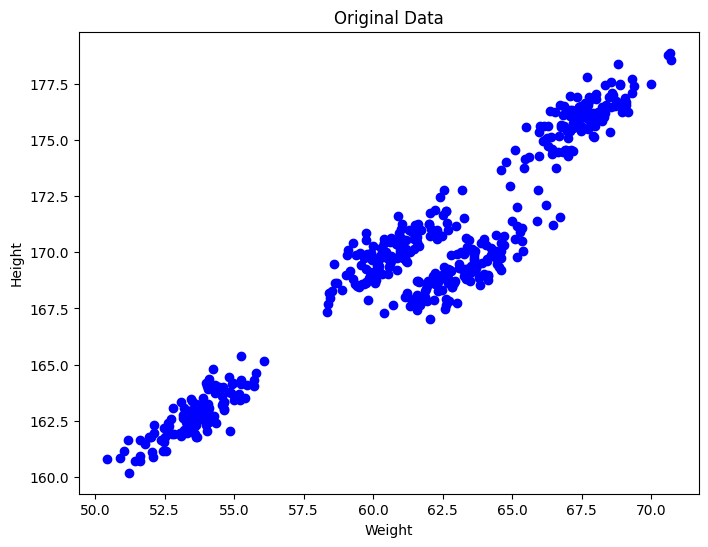

In [11]:
# ==========================================
# Step 11: Original Data Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X['Weight'],
    X['Height'],
    color='blue'
)

plt.title("Original Data")
plt.xlabel("Weight")
plt.ylabel("Height")

plt.show()

In [12]:
# ==========================================
# Step 12: Feature Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

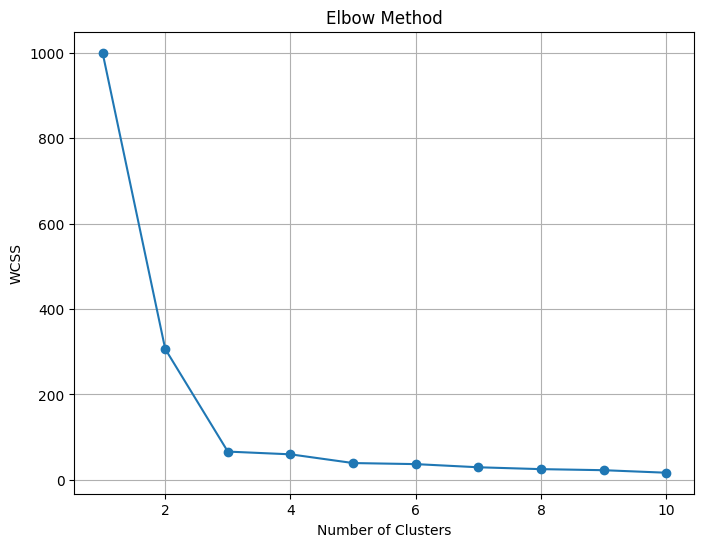

In [13]:
# ==========================================
# Step 13: Elbow Method
# ==========================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [14]:
# ==========================================
# Step 14: Train KMeans Model
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [15]:
# ==========================================
# Step 15: Add Cluster Column
# ==========================================

data["Cluster"] = clusters

print(data.head())

      Weight      Height  Cluster
0  67.062924  176.086355        0
1  68.804094  178.388669        0
2  60.930863  170.284496        2
3  59.733843  168.691992        2
4  65.431230  173.763679        0


In [16]:
# ==========================================
# Step 16: Cluster Centers
# ==========================================

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print(centers)

[[ 67.48841925 175.89645403]
 [ 53.60029808 162.76478198]
 [ 61.92941241 169.62569396]]


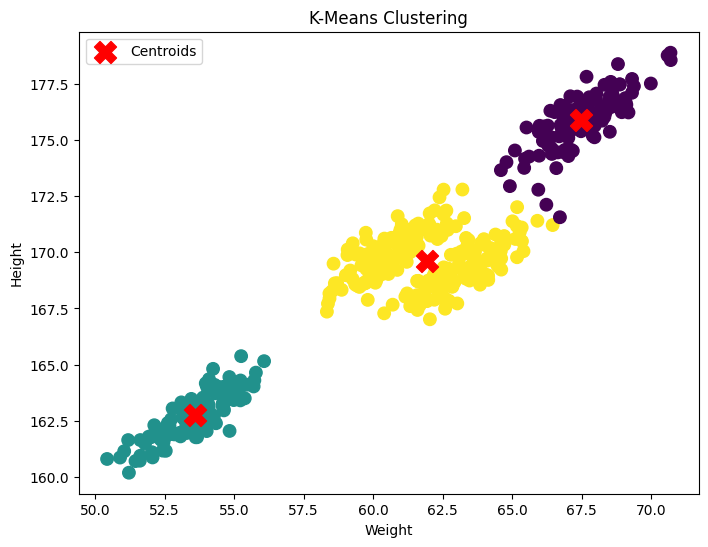

In [17]:
# ==========================================
# Step 17: Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    data["Weight"],
    data["Height"],
    c=data["Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering")

plt.xlabel("Weight")

plt.ylabel("Height")

plt.legend()

plt.show()

In [18]:
# ==========================================
# Step 18: Cluster Counts
# ==========================================

print(data["Cluster"].value_counts())

Cluster
2    247
0    128
1    125
Name: count, dtype: int64


In [19]:
# ==========================================
# Step 19: Final Dataset
# ==========================================

data

,Weight,Height,Cluster
0,67.062924,176.086355,0
1,68.804094,178.388669,0
2,60.930863,170.284496,2
3,59.733843,168.691992,2
4,65.431230,173.763679,0
...,...,...,...
495,59.976983,169.679741,2
496,66.423814,174.625574,0
497,53.604698,161.919208,1
498,50.433644,160.794875,1


In [21]:
from sklearn.metrics import silhouette_score

In [22]:
# ==========================================
# Step 15: Calculate Silhouette Score
# ==========================================

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", round(score, 3))

Silhouette Score : 0.736


In [23]:
# ==========================================
# Find Best K using Silhouette Score
# ==========================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}  --->  Silhouette Score = {score:.3f}")

K = 2  --->  Silhouette Score = 0.662
K = 3  --->  Silhouette Score = 0.736
K = 4  --->  Silhouette Score = 0.632
K = 5  --->  Silhouette Score = 0.503
K = 6  --->  Silhouette Score = 0.513
K = 7  --->  Silhouette Score = 0.506
K = 8  --->  Silhouette Score = 0.503
K = 9  --->  Silhouette Score = 0.513
K = 10  --->  Silhouette Score = 0.455
